# MorphPT vs DINOv3 — 200-gene random-split, LoRA config sweep

Aggregates 4-tissue × 2-LoRA-config × 2-model single-seed runs from `train_lora_multi_probing.py`:

- **Models**: MorphPT + LoRA (`--ckpt_path` = MorphPT router) vs DINOv3 ViT-B/16 + LoRA (`--ckpt_path none`)
- **LoRA configs**: `allblocks` (blocks 0,2,4,6,8,10,11) vs `last4` (blocks 8,9,10,11)
- **Tissues**: mouse_brain, mouse_intestine, mouse_kidney, mouse_embryo
- **Seed**: 42 (single seed; uncertainty is paired per-gene Wilcoxon, not seed variance)

Both models share architecture, LoRA injection, head, and data split — only the backbone init differs.

Outputs paired tables and four plots: grouped bars, DINOv3−MorphPT paired deltas, allblocks−last4 paired deltas, and per-gene scatter.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       220,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlelocation': 'left',
    'axes.titleweight':  'bold',
    'axes.titlesize':    11,
    'legend.frameon':    False,
})

## Configuration

Both models live at `experiments/{exp_tag}_lora_probing_...`. The model is encoded by the exp_tag prefix: MorphPT uses `allblocks`/`last4`; DINOv3 uses `dinov3_allblocks`/`dinov3_last4`. `RUNS` enumerates the 8 (model, exp_tag, config) tuples to load.

In [2]:
TISSUES   = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']
CONFIGS   = ['allblocks', 'last4']
SEED      = 42
N_TOP     = 200
SCALES    = '10.0x'
LOSS      = 'mse'
LAYOUT    = 'default'      # --split_layout default in the slurm script
SELECT_SEED = 42           # --seed in select_top_genes.py

MORPHPT_MODEL_NAME = 'MorphPT + LoRA'
DINOV3_MODEL_NAME  = 'DINOv3 ViT-B/16 + LoRA'

# (model_name, exp_tag_for_path, canonical_config_name)
RUNS = [
    (MORPHPT_MODEL_NAME, 'allblocks',         'allblocks'),
    (MORPHPT_MODEL_NAME, 'last4',             'last4'),
    (DINOV3_MODEL_NAME,  'dinov3_allblocks',  'allblocks'),
    (DINOV3_MODEL_NAME,  'dinov3_last4',      'last4'),
]

MODEL_COLORS = {
    MORPHPT_MODEL_NAME: '#4C72B0',
    DINOV3_MODEL_NAME:  '#DD8452',
}
TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

def results_csv(exp_tag, tissue, seed=SEED):
    folder = f'{exp_tag}_lora_probing_{tissue}_top{N_TOP}_multi_random_{SCALES}_{LOSS}_seed{seed}'
    return PROJECT / 'experiments' / folder / 'multi_lora_hybrid_results.csv'

def rank_csv(tissue):
    return (PROJECT / f'cache_{tissue}' / 'splits' / LAYOUT /
            f'top{N_TOP}_variance_mincov0.1_train_{LAYOUT}_seed{SELECT_SEED}.csv')

print('Expected paths (sample):')
for model, exp_tag, cfg in RUNS:
    print(f'  {model:30s} / {cfg:9s} ->', results_csv(exp_tag, 'mouse_embryo'))
print(f'\nRank CSV (sample): {rank_csv("mouse_embryo")}')

Expected paths (sample):
  MorphPT + LoRA                 / allblocks -> /hpc/group/jilab/tc459/MorphPT/experiments/allblocks_lora_probing_mouse_embryo_top200_multi_random_10.0x_mse_seed42/multi_lora_hybrid_results.csv
  MorphPT + LoRA                 / last4     -> /hpc/group/jilab/tc459/MorphPT/experiments/last4_lora_probing_mouse_embryo_top200_multi_random_10.0x_mse_seed42/multi_lora_hybrid_results.csv
  DINOv3 ViT-B/16 + LoRA         / allblocks -> /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_allblocks_lora_probing_mouse_embryo_top200_multi_random_10.0x_mse_seed42/multi_lora_hybrid_results.csv
  DINOv3 ViT-B/16 + LoRA         / last4     -> /hpc/group/jilab/tc459/MorphPT/experiments/dinov3_last4_lora_probing_mouse_embryo_top200_multi_random_10.0x_mse_seed42/multi_lora_hybrid_results.csv

Rank CSV (sample): /hpc/group/jilab/tc459/MorphPT/cache_mouse_embryo/splits/default/top200_variance_mincov0.1_train_default_seed42.csv


## Load per-gene results

In [3]:
def load_run(model_name, exp_tag, config, tissue, seed=SEED):
    rcsv = results_csv(exp_tag, tissue, seed)
    kcsv = rank_csv(tissue)
    if not rcsv.exists():
        return None, ('result_missing', str(rcsv))
    if not kcsv.exists():
        return None, ('rank_missing', str(kcsv))

    res   = pd.read_csv(rcsv)
    ranks = pd.read_csv(kcsv)[['gene_idx', 'rank']]
    merged = res.merge(ranks, on='gene_idx', how='left')

    test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
    val_col  = next(c for c in merged.columns if c.startswith('val_pearson_s'))

    out = pd.DataFrame({
        'model':        model_name,
        'config':       config,
        'exp_tag':      exp_tag,
        'tissue':       tissue,
        'seed':         seed,
        'gene_idx':     merged['gene_idx'].astype(int),
        'gene_name':    merged['gene_name'],
        'rank':         merged['rank'].astype('Int64'),
        'test_pearson': merged[test_col].astype(float),
        'val_pearson':  merged[val_col].astype(float),
    })
    return out, None

rows, missing = [], []
for model, exp_tag, cfg in RUNS:
    for tissue in TISSUES:
        df_run, err = load_run(model, exp_tag, cfg, tissue)
        if err is not None:
            missing.append((model, cfg, tissue, *err))
        else:
            rows.append(df_run)

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print(f'Loaded {len(df):,} (gene, model, config, tissue) rows from '
      f'{df.groupby(["model","config","tissue"]).ngroups if len(df) else 0} runs')

if missing:
    print(f'\nMissing ({len(missing)}):')
    for m in missing:
        print('  ', m[0], '|', m[1], '|', m[2], '|', m[3], '->', m[4])

Loaded 3,200 (gene, model, config, tissue) rows from 16 runs


## Per-run summary

In [4]:
per_run = (df.groupby(['model', 'tissue', 'config'])
             .agg(mean_test_r   = ('test_pearson', 'mean'),
                  median_test_r = ('test_pearson', 'median'),
                  n_genes       = ('gene_idx',     'count'))
             .reset_index())

pivot = per_run.pivot(index='tissue', columns=['model', 'config'], values='mean_test_r')
pivot = pivot.reindex(TISSUES)
col_order = [(MORPHPT_MODEL_NAME, c) for c in CONFIGS] + [(DINOV3_MODEL_NAME, c) for c in CONFIGS]
pivot = pivot[[c for c in col_order if c in pivot.columns]]
print('Mean test Pearson r (tissue × model/config):\n')
print(pivot.round(4))
per_run.to_csv('morphpt_vs_dinov3_lora_configs_per_run.csv', index=False)

Mean test Pearson r (tissue × model/config):

model           MorphPT + LoRA         DINOv3 ViT-B/16 + LoRA        
config               allblocks   last4              allblocks   last4
tissue                                                               
mouse_brain             0.3613  0.3479                 0.3538  0.3465
mouse_intestine         0.4015  0.3955                 0.4018  0.3953
mouse_kidney            0.4716  0.4647                 0.4704  0.4637
mouse_embryo            0.3267  0.3152                 0.3235  0.3139


## Paired analysis

Two paired contrasts, both at the per-gene level (matched on shared `gene_idx`):

- `delta_dinov3_minus_morphpt` per (tissue, config) — **model effect**
- `delta_allblocks_minus_last4` per (tissue, model) — **LoRA config effect**

Two-sided Wilcoxon signed-rank p-values reported on per-gene deltas. `frac_*_wins` = fraction of genes where the right-hand term beats the left.

In [5]:
# Helper
def wilcoxon_p(g, col):
    deltas = g[col].to_numpy()
    if len(deltas) < 5 or np.allclose(deltas, 0):
        return np.nan
    try:
        return stats.wilcoxon(deltas, zero_method='wilcox', alternative='two-sided').pvalue
    except ValueError:
        return np.nan

# --- Model contrast: DINOv3 - MorphPT, within each (tissue, config) ---
m_df = df[df['model'] == MORPHPT_MODEL_NAME]
d_df = df[df['model'] == DINOV3_MODEL_NAME]

model_paired = m_df.merge(
    d_df,
    on=['tissue', 'config', 'seed', 'gene_idx', 'gene_name', 'rank'],
    suffixes=('_morphpt', '_dinov3'),
)
model_paired['delta_dinov3_minus_morphpt'] = (
    model_paired['test_pearson_dinov3'] - model_paired['test_pearson_morphpt']
)

model_compare = (model_paired.groupby(['tissue', 'config'])
                 .agg(morphpt_mean = ('test_pearson_morphpt', 'mean'),
                      dinov3_mean  = ('test_pearson_dinov3',  'mean'),
                      mean_delta   = ('delta_dinov3_minus_morphpt', 'mean'),
                      median_delta = ('delta_dinov3_minus_morphpt', 'median'),
                      frac_dino_wins = ('delta_dinov3_minus_morphpt',
                                        lambda s: float((s > 0).mean())),
                      n_genes      = ('gene_idx', 'count'))
                 .reset_index())

wilcox_md = (model_paired.groupby(['tissue', 'config'])
             .apply(lambda g: wilcoxon_p(g, 'delta_dinov3_minus_morphpt'),
                    include_groups=False)
             .rename('wilcoxon_p').reset_index())
model_compare = model_compare.merge(wilcox_md, on=['tissue', 'config'])

print('Model contrast (DINOv3 - MorphPT) per (tissue, config):\n')
print(model_compare.round(5).to_string(index=False))
model_compare.to_csv('morphpt_vs_dinov3_lora_configs_model_contrast.csv', index=False)

Model contrast (DINOv3 - MorphPT) per (tissue, config):

         tissue    config  morphpt_mean  dinov3_mean  mean_delta  median_delta  frac_dino_wins  n_genes  wilcoxon_p
    mouse_brain allblocks       0.36125      0.35383    -0.00742      -0.00687           0.165      200     0.00000
    mouse_brain     last4       0.34789      0.34655    -0.00134      -0.00161           0.415      200     0.00048
   mouse_embryo allblocks       0.32667      0.32352    -0.00315      -0.00283           0.075      200     0.00000
   mouse_embryo     last4       0.31522      0.31390    -0.00132      -0.00126           0.295      200     0.00000
mouse_intestine allblocks       0.40147      0.40179     0.00032       0.00062           0.575      200     0.05859
mouse_intestine     last4       0.39547      0.39531    -0.00016       0.00028           0.550      200     0.92515
   mouse_kidney allblocks       0.47159      0.47039    -0.00120      -0.00123           0.285      200     0.00000
   mouse_kidney

In [6]:
# --- Config contrast: allblocks - last4, within each (tissue, model) ---
a_df = df[df['config'] == 'allblocks']
l_df = df[df['config'] == 'last4']

config_paired = a_df.merge(
    l_df,
    on=['model', 'tissue', 'seed', 'gene_idx', 'gene_name', 'rank'],
    suffixes=('_allblocks', '_last4'),
)
config_paired['delta_allblocks_minus_last4'] = (
    config_paired['test_pearson_allblocks'] - config_paired['test_pearson_last4']
)

config_compare = (config_paired.groupby(['model', 'tissue'])
                  .agg(allblocks_mean = ('test_pearson_allblocks', 'mean'),
                       last4_mean     = ('test_pearson_last4',     'mean'),
                       mean_delta     = ('delta_allblocks_minus_last4', 'mean'),
                       median_delta   = ('delta_allblocks_minus_last4', 'median'),
                       frac_all_wins  = ('delta_allblocks_minus_last4',
                                         lambda s: float((s > 0).mean())),
                       n_genes        = ('gene_idx', 'count'))
                  .reset_index())

wilcox_cd = (config_paired.groupby(['model', 'tissue'])
             .apply(lambda g: wilcoxon_p(g, 'delta_allblocks_minus_last4'),
                    include_groups=False)
             .rename('wilcoxon_p').reset_index())
config_compare = config_compare.merge(wilcox_cd, on=['model', 'tissue'])

print('Config contrast (allblocks - last4) per (model, tissue):\n')
print(config_compare.round(5).to_string(index=False))
config_compare.to_csv('morphpt_vs_dinov3_lora_configs_config_contrast.csv', index=False)

Config contrast (allblocks - last4) per (model, tissue):

                 model          tissue  allblocks_mean  last4_mean  mean_delta  median_delta  frac_all_wins  n_genes  wilcoxon_p
DINOv3 ViT-B/16 + LoRA     mouse_brain         0.35383     0.34655     0.00728       0.00758          0.885      200         0.0
DINOv3 ViT-B/16 + LoRA    mouse_embryo         0.32352     0.31390     0.00963       0.00865          1.000      200         0.0
DINOv3 ViT-B/16 + LoRA mouse_intestine         0.40179     0.39531     0.00648       0.00569          0.980      200         0.0
DINOv3 ViT-B/16 + LoRA    mouse_kidney         0.47039     0.46368     0.00671       0.00616          1.000      200         0.0
        MorphPT + LoRA     mouse_brain         0.36125     0.34789     0.01336       0.01242          0.970      200         0.0
        MorphPT + LoRA    mouse_embryo         0.32667     0.31522     0.01145       0.01141          1.000      200         0.0
        MorphPT + LoRA mouse_intestine 

## Plot 1 — grouped bars: tissue × model × config

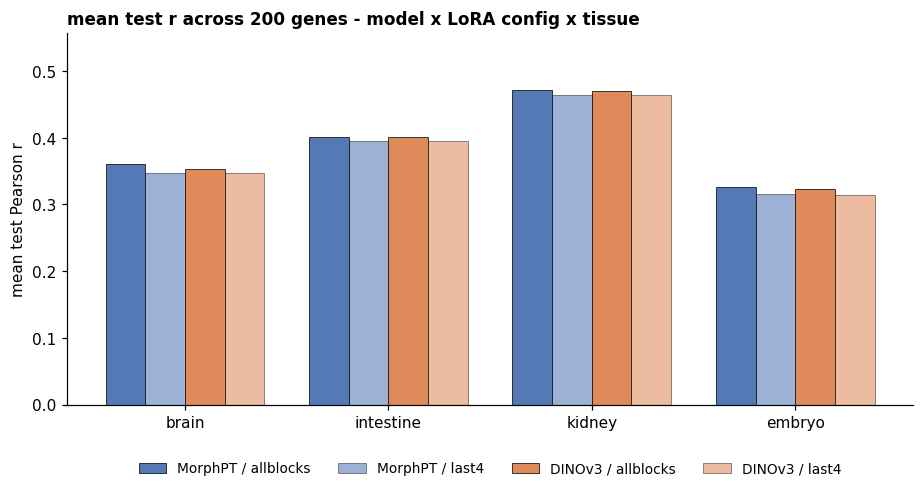

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
xs = np.arange(len(TISSUES))
group_width = 0.78
bar_width   = group_width / 4

combos = [
    (MORPHPT_MODEL_NAME, 'allblocks'),
    (MORPHPT_MODEL_NAME, 'last4'),
    (DINOV3_MODEL_NAME,  'allblocks'),
    (DINOV3_MODEL_NAME,  'last4'),
]
offsets = np.linspace(-group_width/2 + bar_width/2,
                       group_width/2 - bar_width/2, 4)

for off, (model, cfg) in zip(offsets, combos):
    ys = [per_run[(per_run['model'] == model) &
                  (per_run['tissue'] == t) &
                  (per_run['config'] == cfg)]['mean_test_r'].values
          for t in TISSUES]
    ys = [float(y[0]) if len(y) else np.nan for y in ys]
    color = MODEL_COLORS[model]
    alpha = 0.95 if cfg == 'allblocks' else 0.55
    ax.bar(xs + off, ys, bar_width,
           color=color, alpha=alpha,
           edgecolor='black', linewidth=0.5,
           label=f'{model.split(" ")[0]} / {cfg}')

ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('mean test Pearson r')
ax.set_title('mean test r across 200 genes - model x LoRA config x tissue')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9)

all_vals = per_run['mean_test_r'].dropna()
ax.set_ylim(0, all_vals.max() * 1.18)

plt.tight_layout()
plt.savefig('plot_lora_configs_grouped_bars.pdf', bbox_inches='tight')
plt.show()

## Plot 2 — paired model deltas (DINOv3 − MorphPT) per (tissue, config)

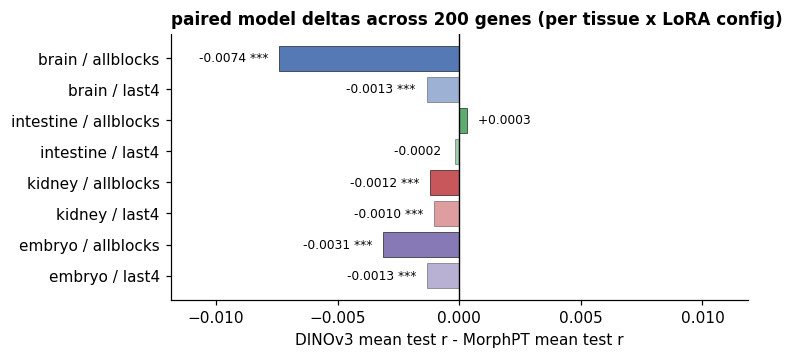

In [8]:
order = [(t, c) for t in TISSUES for c in CONFIGS]
plot_md = (model_compare
           .set_index(['tissue', 'config'])
           .reindex(order)
           .reset_index())
plot_md['label'] = plot_md['tissue'].str.replace('mouse_', '', regex=False) + ' / ' + plot_md['config']

fig, ax = plt.subplots(figsize=(7.0, max(3.2, 0.42 * len(plot_md))))
y = np.arange(len(plot_md))
colors = [TISSUE_COLORS[t] for t in plot_md['tissue']]
alphas = [0.95 if c == 'allblocks' else 0.55 for c in plot_md['config']]

bars = ax.barh(y, plot_md['mean_delta'],
               color=colors, edgecolor='black', linewidth=0.4)
for b, a in zip(bars, alphas):
    b.set_alpha(a)

ax.axvline(0, color='black', linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(plot_md['label'])
ax.invert_yaxis()
ax.set_xlabel('DINOv3 mean test r - MorphPT mean test r')
ax.set_title('paired model deltas across 200 genes (per tissue x LoRA config)')

xmax = plot_md['mean_delta'].abs().max()
pad  = xmax * 0.06 if xmax > 0 else 1e-3
for yi, (val, p) in enumerate(zip(plot_md['mean_delta'], plot_md['wilcoxon_p'])):
    ha = 'left' if val >= 0 else 'right'
    xoff = pad if val >= 0 else -pad
    star = '***' if p < 1e-3 else ('**' if p < 1e-2 else ('*' if p < 5e-2 else ''))
    ax.text(val + xoff, yi, f'{val:+.4f} {star}', ha=ha, va='center', fontsize=8)

ax.set_xlim(-xmax * 1.6, xmax * 1.6)

plt.tight_layout()
plt.savefig('plot_lora_configs_model_deltas.pdf', bbox_inches='tight')
plt.show()

## Plot 3 — paired config deltas (allblocks − last4) per (tissue, model)

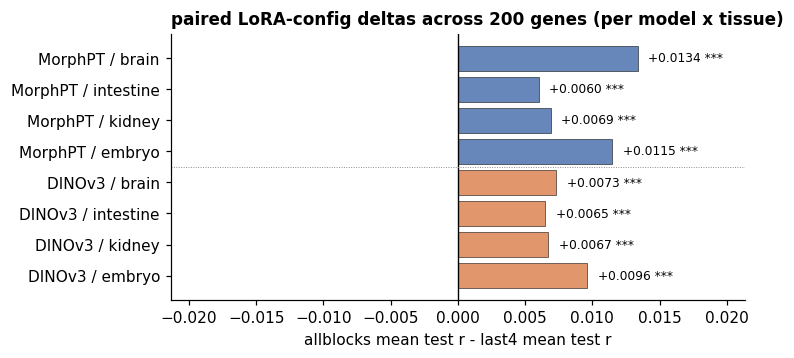

In [9]:
order_cfg = [(m, t) for m in [MORPHPT_MODEL_NAME, DINOV3_MODEL_NAME] for t in TISSUES]
plot_cd = (config_compare
           .set_index(['model', 'tissue'])
           .reindex(order_cfg)
           .reset_index())
plot_cd['label'] = (plot_cd['model'].str.split(' ').str[0] + ' / '
                    + plot_cd['tissue'].str.replace('mouse_', '', regex=False))

fig, ax = plt.subplots(figsize=(7.0, max(3.2, 0.42 * len(plot_cd))))
y = np.arange(len(plot_cd))
colors = [MODEL_COLORS[m] for m in plot_cd['model']]

bars = ax.barh(y, plot_cd['mean_delta'],
               color=colors, alpha=0.85,
               edgecolor='black', linewidth=0.4)

ax.axvline(0, color='black', linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(plot_cd['label'])
ax.invert_yaxis()
ax.set_xlabel('allblocks mean test r - last4 mean test r')
ax.set_title('paired LoRA-config deltas across 200 genes (per model x tissue)')

xmax_c = plot_cd['mean_delta'].abs().max()
pad_c  = xmax_c * 0.06 if xmax_c > 0 else 1e-3
for yi, (val, p) in enumerate(zip(plot_cd['mean_delta'], plot_cd['wilcoxon_p'])):
    ha = 'left' if val >= 0 else 'right'
    xoff = pad_c if val >= 0 else -pad_c
    star = '***' if p < 1e-3 else ('**' if p < 1e-2 else ('*' if p < 5e-2 else ''))
    ax.text(val + xoff, yi, f'{val:+.4f} {star}', ha=ha, va='center', fontsize=8)

ax.set_xlim(-xmax_c * 1.6, xmax_c * 1.6)
ax.axhline(len(TISSUES) - 0.5, color='gray', linewidth=0.6, linestyle=':')

plt.tight_layout()
plt.savefig('plot_lora_configs_config_deltas.pdf', bbox_inches='tight')
plt.show()

## Plot 4 — per-gene MorphPT vs DINOv3 scatter, split by config

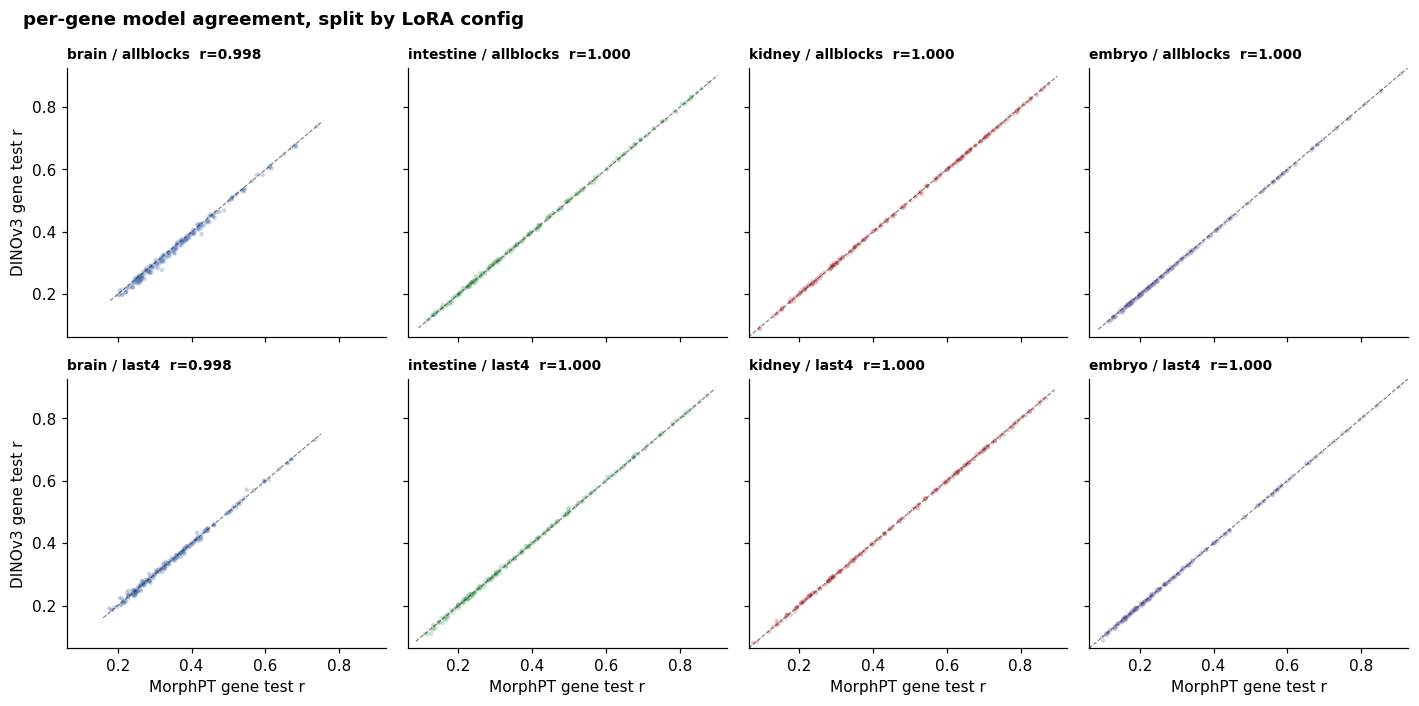

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), sharex=True, sharey=True)

for col_idx, tissue in enumerate(TISSUES):
    for row_idx, cfg in enumerate(CONFIGS):
        ax = axes[row_idx, col_idx]
        sub = model_paired[(model_paired['tissue'] == tissue) &
                            (model_paired['config'] == cfg)]
        if sub.empty:
            ax.set_visible(False)
            continue
        corr = sub[['test_pearson_morphpt', 'test_pearson_dinov3']].corr().iloc[0, 1]
        ax.scatter(sub['test_pearson_morphpt'], sub['test_pearson_dinov3'],
                   s=8, alpha=0.30, color=TISSUE_COLORS[tissue], edgecolors='none')
        lim_min = min(sub['test_pearson_morphpt'].min(), sub['test_pearson_dinov3'].min())
        lim_max = max(sub['test_pearson_morphpt'].max(), sub['test_pearson_dinov3'].max())
        pad = 0.03 * (lim_max - lim_min)
        ax.plot([lim_min - pad, lim_max + pad], [lim_min - pad, lim_max + pad],
                color='black', linestyle='--', linewidth=0.7, alpha=0.55)
        ax.set_title(f'{tissue.replace("mouse_", "")} / {cfg}  r={corr:.3f}', fontsize=9)
        ax.set_xlim(lim_min - pad, lim_max + pad)
        ax.set_ylim(lim_min - pad, lim_max + pad)
        if col_idx == 0:
            ax.set_ylabel('DINOv3 gene test r')
        if row_idx == 1:
            ax.set_xlabel('MorphPT gene test r')

fig.suptitle('per-gene model agreement, split by LoRA config',
             fontsize=12, fontweight='bold', x=0.02, ha='left')
plt.tight_layout()
plt.savefig('plot_lora_configs_gene_scatter.pdf', bbox_inches='tight')
plt.show()

## Files saved

CSVs:
- `morphpt_vs_dinov3_lora_configs_per_run.csv` — mean test r per (model, tissue, config)
- `morphpt_vs_dinov3_lora_configs_model_contrast.csv` — DINOv3−MorphPT delta per (tissue, config) + Wilcoxon p
- `morphpt_vs_dinov3_lora_configs_config_contrast.csv` — allblocks−last4 delta per (model, tissue) + Wilcoxon p

Plots (PDF):
- `plot_lora_configs_grouped_bars.pdf` — headline 4-way bar chart
- `plot_lora_configs_model_deltas.pdf` — paired DINOv3−MorphPT deltas
- `plot_lora_configs_config_deltas.pdf` — paired allblocks−last4 deltas
- `plot_lora_configs_gene_scatter.pdf` — per-gene scatter